# Práctica 2A: K-Means

## Realizado por: Eduardo Alanís García

## Instrucciones

1. Leer el conjunto de datos del archivo `kmeans-elbow.npy`.
2. Aplicar la **técnica del codo** para estimar el mejor parámetro $k$ del algoritmo k-means.
3. Graficar la métrica **silueta** para diferentes valores de $k$ y comparar con la técnica anterior.
4. Elegir el parámetro $k$ que se crea conveniente basado en los resultados anteriores.
5. Contestar la evaluación de esta práctica en el Aula Virtual.

Nota. El archivo se puede leer con el siguiente código:

`X = np.load('<ruta>/kmeans-elbow.npy')`

### Cargar google drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Importar librerías

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### Verificar existencia del archivo

In [3]:
direccion = "/content/drive/MyDrive/MCDI-INFOTEC/1. Primer semestre/Manejo y procesamiento de la informacion/Unidad 2/Práctica 2A K-Means/"

archivo = "kmeans-elbow.npy"
ruta = os.path.join(direccion, archivo)
print(archivo, "Existe" if os.path.exists(ruta) else "No Existe")

kmeans-elbow.npy Existe


## 1. Lee el conjunto de datos del archivo kmeans-elbow.npy

In [12]:
X = np.load(ruta)
X

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  3., ...,  9.,  0.,  0.],
       [ 0.,  0.,  0., ...,  6.,  0.,  0.],
       [ 0.,  0.,  9., ..., 10.,  0.,  0.]])

In [17]:
print(f"Dimenciones: {X.shape}")
print(f"Valor mínimo: {X.min()}, valor máximo: {X.max()}")
print(f"Tipo de dato: {type(X)}")

Dimenciones: (1000, 64)
Valor mínimo: 0.0, valor máximo: 16.0
Tipo de dato: <class 'numpy.ndarray'>


## 2. Aplica la técnica del codo para estimar el mejor parámetro k del algoritmo k-means

La suma de los cuadrados de las distancias (SSE) de cada punto a su centroide se guarda en el atributo `inertia_`. Este valor disminuye cuando $k$ crece, por lo que en la gráfica se busca el punto donde la curva deja de bajar rápidamente (el "codo").



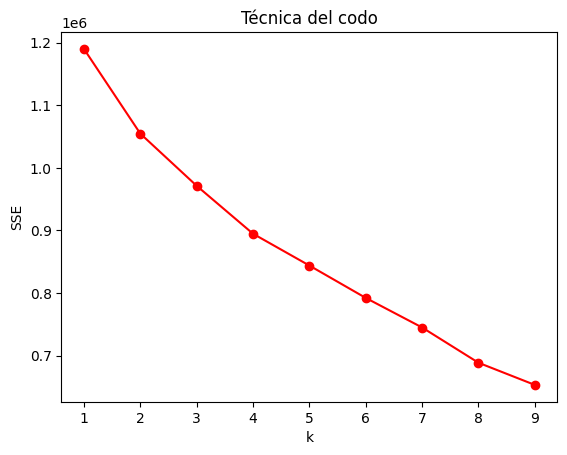

In [23]:
k_range = list(range(1, 10))
sse = []

for k in k_range:
  km = KMeans(n_clusters=k, n_init='auto', random_state=1)
  km.fit(X)
  sse.append(km.inertia_)

plt.plot(k_range, sse, '-or')
plt.xticks(k_range)
plt.xlabel("k")
plt.ylabel('SSE')
plt.title('Técnica del codo')
plt.show()

Para ver mejor dónde cambia la pendiente, calculamos cuánto disminuye el SSE al pasar de $k-1$ a $k$.

In [24]:
for i in range(len(k_range)):
  if i == 0:
    print(f"Para k: {k_range[i]} tenemos SSE:{sse[i]:.1f}")
  else:
    diferencia = sse[i-1] - sse[i]
    print(f"Para k: {k_range[i]}  tenemos SSE:{sse[i]:.1f} donde existe una disminución de {diferencia:.1f}")

Para k: 1 tenemos SSE:1190021.6
Para k: 2  tenemos SSE:1054672.5 donde existe una disminución de 135349.1
Para k: 3  tenemos SSE:971246.9 donde existe una disminución de 83425.6
Para k: 4  tenemos SSE:894630.9 donde existe una disminución de 76616.0
Para k: 5  tenemos SSE:843778.0 donde existe una disminución de 50852.9
Para k: 6  tenemos SSE:792062.6 donde existe una disminución de 51715.4
Para k: 7  tenemos SSE:744794.3 donde existe una disminución de 47268.3
Para k: 8  tenemos SSE:688461.8 donde existe una disminución de 56332.5
Para k: 9  tenemos SSE:653034.9 donde existe una disminución de 35426.9


La SSE disminuye conforme aumenta k. En la gráfica se observa un cambio de pendiente alrededor de k = 4; después de ese punto la curva sigue bajando de forma más gradual. El codo no es muy pronunciado, así que conviene comparar este resultado con la silueta.

## 3. Grafica la métrica silueta para diferentes valores de k y compara con la técnica anterior

La silueta se calcula con `silhouette_score` y necesita al menos 2 clusters. Mientras más alto es el valor, mejor se considera la separación de los clusters.

Para k = 2 la Silueta es0.11852808317692785
Para k = 3 la Silueta es0.11160300831855
Para k = 4 la Silueta es0.12179349138962683
Para k = 5 la Silueta es0.13035454581693173
Para k = 6 la Silueta es0.1451730066826893
Para k = 7 la Silueta es0.16158957126087026
Para k = 8 la Silueta es0.17687952550618732
Para k = 9 la Silueta es0.19062369170512555


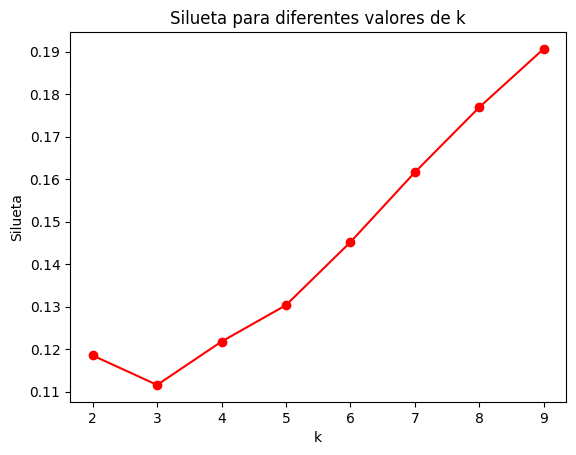

El valor máximo de silueta es 0.19062369170512555 con k = 9


In [26]:
sil = []
k_range_sil = list(range(2, 10))

for k in k_range_sil:
  km = KMeans(n_clusters=k, n_init='auto', random_state=1)
  y_km = km.fit_predict(X)
  score = silhouette_score(X, y_km, metric='euclidean')
  sil.append(score)
  print(f"Para k = {k} la Silueta es{score}")

plt.plot(k_range_sil, sil, '-or')
plt.xticks(k_range_sil)
plt.xlabel("k")
plt.ylabel('Silueta')
plt.title('Silueta para diferentes valores de k')
plt.show()

mejor_k = k_range_sil[sil.index(max(sil))]
print(f"El valor máximo de silueta es {max(sil)} con k = {mejor_k}")

La silueta compara qué tan cerca están los datos de los elementos de su propio cluster frente a los de otros clusters. Donde recordemos que valores mayores representan una mejor separación relativa.

## 4. Elige el parámetro k que creas conveniente basado en los resultados anteriores

Considero que una elección razonable es **k = 4 clusters**. Mediante el método del codo, se observa que la SSE disminuye con mayor rapidez en los primeros valores de k y que la curva presenta un cambio de pendiente alrededor de k = 4. A partir de ese punto, las reducciones son menores en general.

Por otro lado, el coeficiente de silueta no confirma claramente esta elección, ya que aumenta a lo largo de todo el rango evaluado y alcanza su máximo en k = 9, con un valor de 0.1906. Además, para k = 4, su valor es de 0.1218, lo que indica que los grupos no están muy bien separados.

A pesar de la diferencia entre ambos métodos, elijo k = 4 porque es donde la curva empieza a cambiar y permite mantener una solución más sencilla. Por lo tanto, considero que es una estimación razonable para estos datos, aunque no se puede asegurar que sea la única cantidad correcta.


In [34]:
K = 4
km = KMeans(n_clusters=K, n_init='auto', random_state=1)
y_km = km.fit_predict(X)

print(f"k elegida: {K}")
print(f"SSE: {km.inertia_}")
print(f"Silueta: {silhouette_score(X, y_km, metric='euclidean')}")
print(f"Muestras por cluster: {np.bincount(y_km)}")

k elegida: 4
SSE: 894630.8663449348
Silueta: 0.12179349138962683
Muestras por cluster: [233 242 197 328]


## Ejercicio 5: Contestar la evaluación de esta práctica en el Aula Virtual

